# 02 — Базовые ML-модели (NIJ)

Логистическая регрессия, Random Forest и XGBoost — точка отсчёта для гибридной нейросети (п. 4 календарного плана ИПМ).

Оценка на **официальном тестовом сплите** NIJ: AUC-ROC, F1, точность, Brier score, ECE (калибровка) + SHAP-интерпретация лучшей модели.

In [1]:
import sys
sys.path.insert(0, "../src")

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import RocCurveDisplay

from recidivism.baselines import make_baselines
from recidivism.data import prepare_nij
from recidivism.metrics import classification_metrics

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

data = prepare_nij("../data/raw/nij_recidivism_full.csv")
print("train:", data.X_train.shape, "| test:", data.X_test.shape)

train: (18028, 63) | test: (7807, 63)


In [2]:
# Обучение бейзлайнов и расчёт метрик
models = make_baselines(seed=42)
probs, rows = {}, []
for name, model in models.items():
    model.fit(data.X_train, data.y_train)
    probs[name] = model.predict_proba(data.X_test)[:, 1]
    rows.append({"model": name, **classification_metrics(data.y_test, probs[name])})

metrics_df = pd.DataFrame(rows).set_index("model").sort_values("roc_auc", ascending=False)
metrics_df.round(4)

,roc_auc,f1,accuracy,precision,recall,brier,ece
model,,,,,,,
xgboost,0.8196,0.7913,0.7491,0.7573,0.8285,0.1688,0.0202
random_forest,0.8051,0.7911,0.7395,0.7330,0.8592,0.1780,0.0518
logreg,0.7898,0.7784,0.7313,0.7392,0.8220,0.1812,0.0151


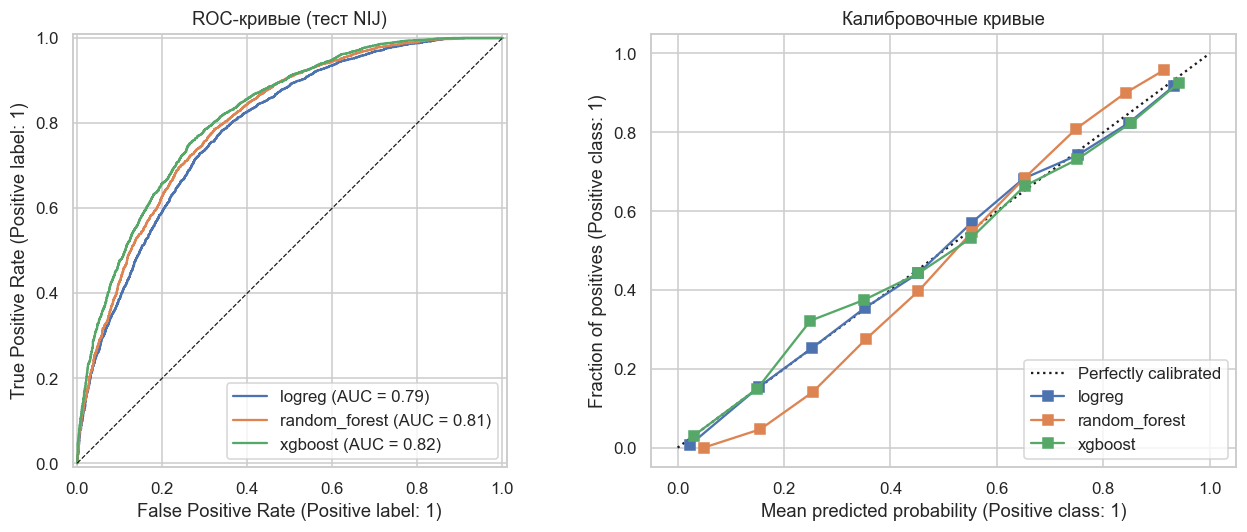

In [3]:
# ROC-кривые и калибровка
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for name, p in probs.items():
    RocCurveDisplay.from_predictions(data.y_test, p, name=name, ax=axes[0])
    CalibrationDisplay.from_predictions(data.y_test, p, name=name, n_bins=10, ax=axes[1])
axes[0].plot([0, 1], [0, 1], "k--", lw=0.8)
axes[0].set_title("ROC-кривые (тест NIJ)")
axes[1].set_title("Калибровочные кривые")
plt.tight_layout()
plt.show()

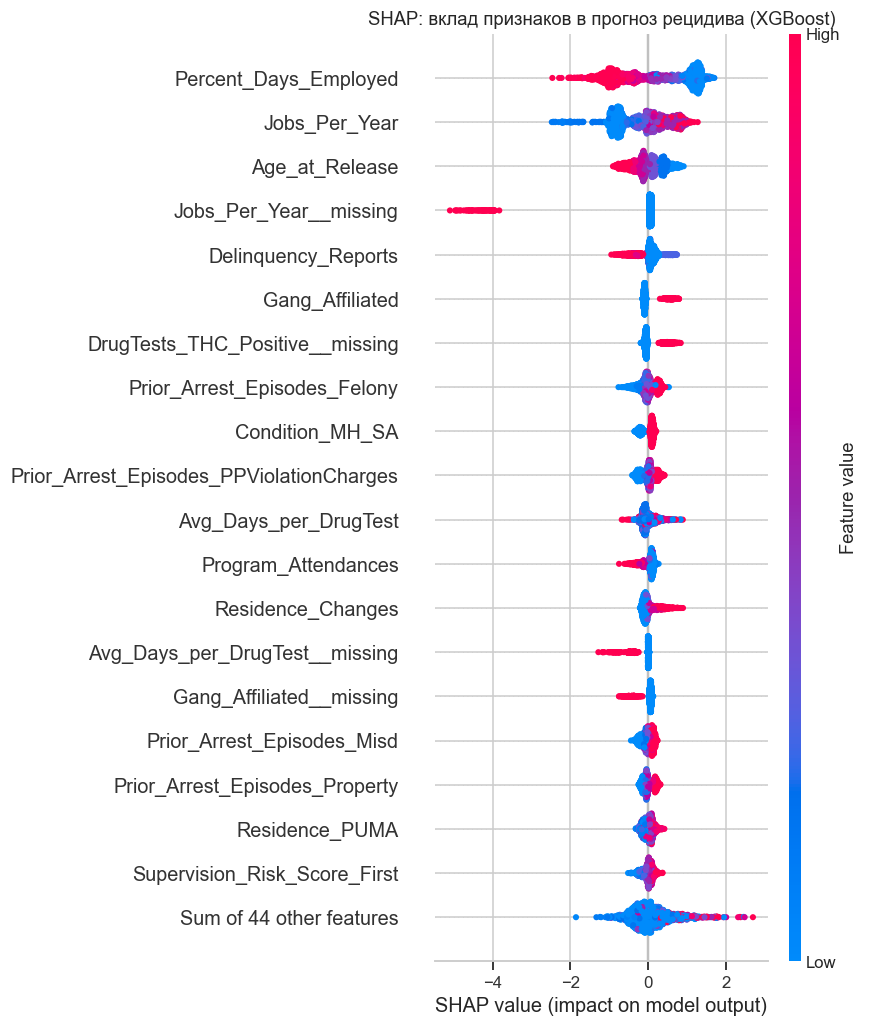

In [4]:
# SHAP-интерпретация лучшей модели (XGBoost)
import shap

from recidivism.explain import shap_tree_values

explainer, shap_values, X_sample = shap_tree_values(models["xgboost"], data.X_test, max_samples=2000)
shap.plots.beeswarm(shap_values, max_display=20, show=False)
plt.title("SHAP: вклад признаков в прогноз рецидива (XGBoost)")
plt.tight_layout()
plt.show()

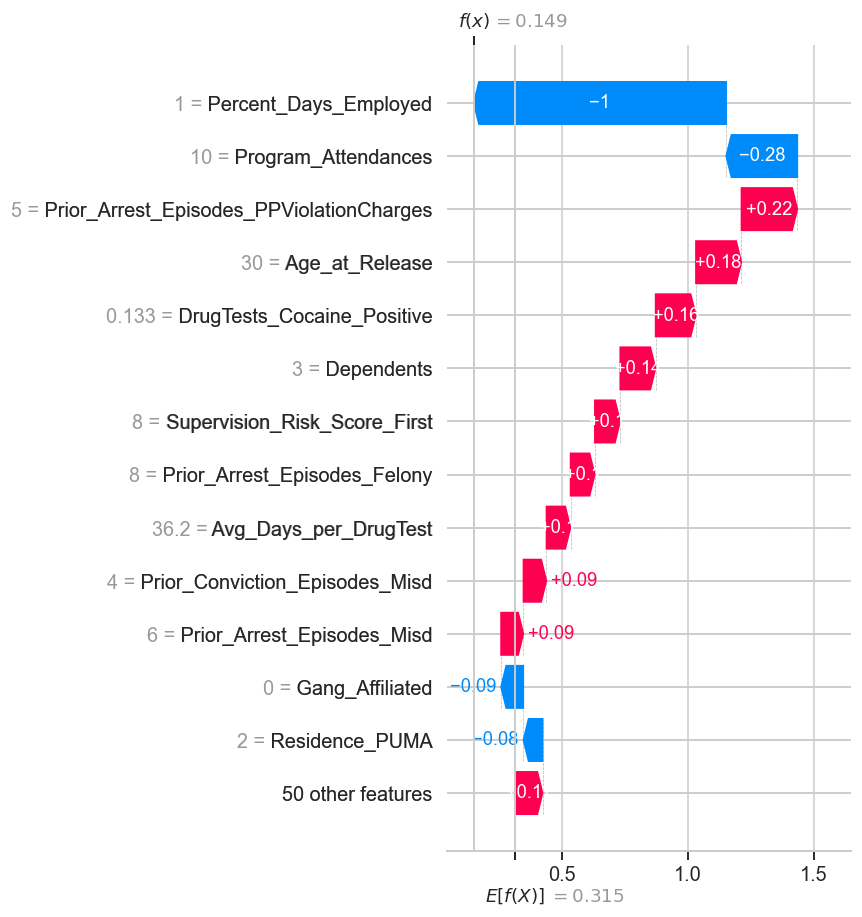

In [5]:
# Локальное объяснение: почему модель дала такой прогноз конкретному человеку
shap.plots.waterfall(shap_values[0], max_display=14, show=False)
plt.tight_layout()
plt.show()